In [26]:
#Importing All Required Libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
male_ind = len(train[train['Sex'] == 'male'])
print("No of Males in Titanic:",male_ind)

female_ind = len(train[train['Sex'] == 'female'])
print("No of Females in Titanic:",female_ind)

No of Males in Titanic: 577
No of Females in Titanic: 314


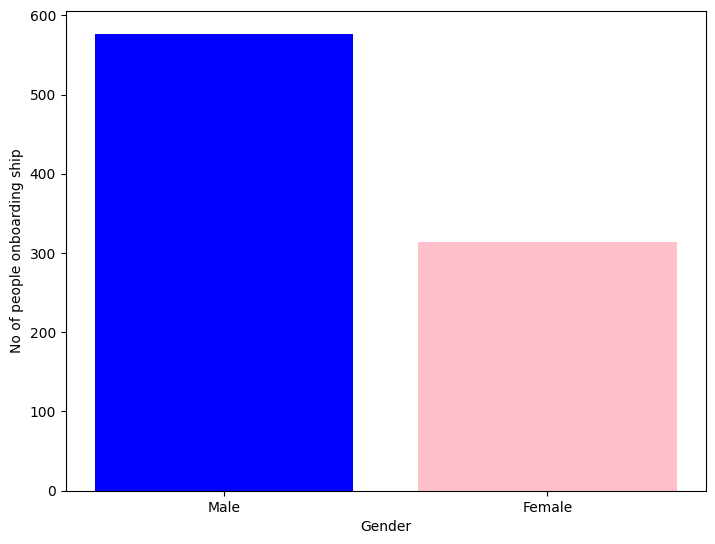

In [32]:
#Plotting
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
gender = ['Male','Female']
index = [male_ind,female_ind]
ax.bar(gender,index, color=['blue','pink'])
plt.xlabel("Gender")
plt.ylabel("No of people onboarding ship")
plt.show()

In [33]:
alive = len(train[train['Survived'] == 1])
dead = len(train[train['Survived'] == 0])
print("No of people alive in Titanic:",alive)
print("No of people dead in Titanic:",dead)

No of people alive in Titanic: 342
No of people dead in Titanic: 549


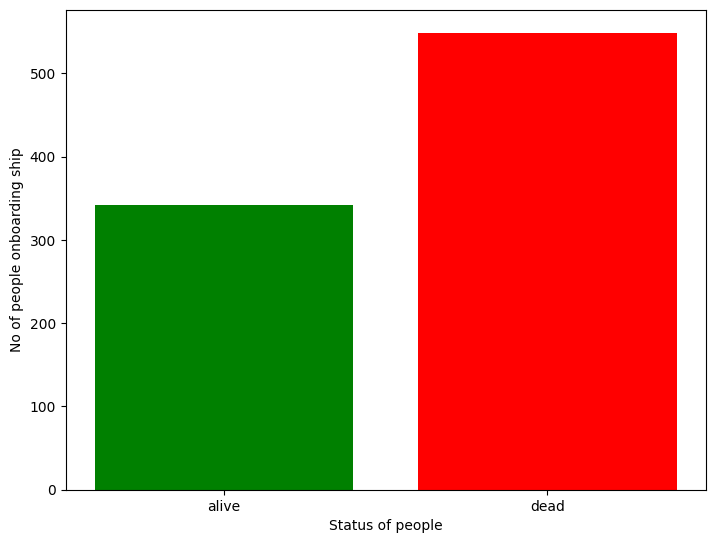

In [34]:
#Plotting
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
gender = ['alive','dead']
index = [alive,dead]
ax.bar(gender,index, color=['green','red'])
plt.xlabel("Status of people")
plt.ylabel("No of people onboarding ship")
plt.show()

In [35]:
# survival percentage by gender
survival_pct = train.groupby('Sex')[['Survived']].mean() * 100
print(survival_pct)


         Survived
Sex              
female  74.203822
male    18.890815


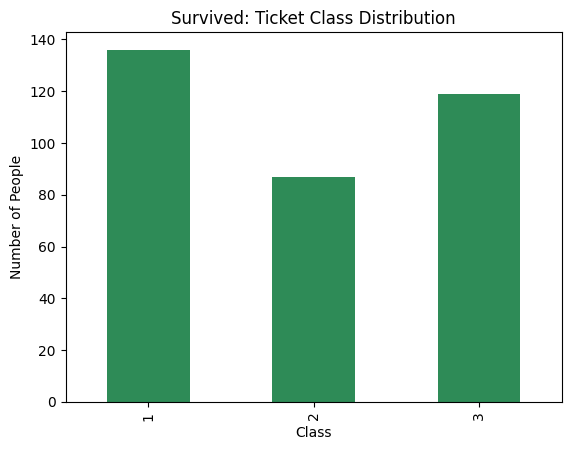

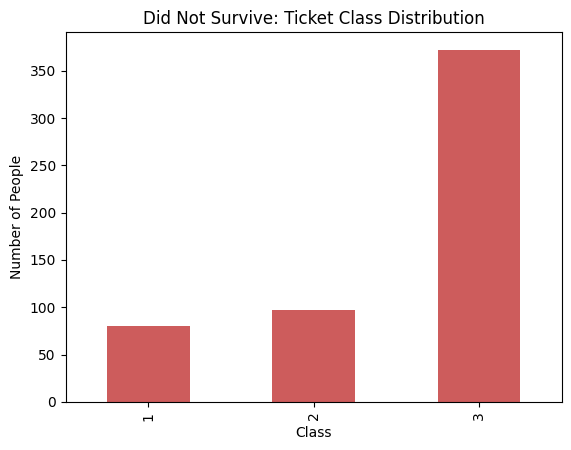

In [37]:
# Figure 1: Survived (Green bars)
plt.figure(1)
train.loc[train['Survived'] == 1, 'Pclass'].value_counts().sort_index().plot.bar(color='seagreen')
plt.title('Survived: Ticket Class Distribution')
plt.xlabel("Class")
plt.ylabel("Number of People")

# Figure 2: Deceased (Red bars)
plt.figure(2)
train.loc[train['Survived'] == 0, 'Pclass'].value_counts().sort_index().plot.bar(color='indianred')
plt.title('Did Not Survive: Ticket Class Distribution')
plt.xlabel("Class")
plt.ylabel("Number of People")

plt.show()

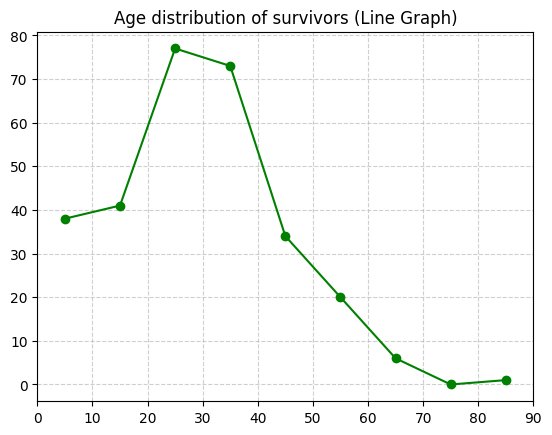

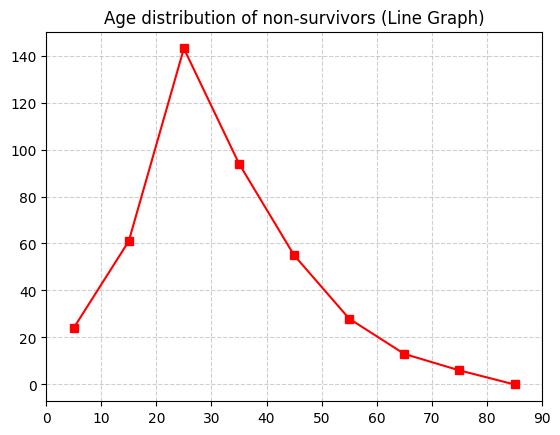

In [38]:
# Define your bins once
bins = np.arange(0, 100, 10)
# Calculate the center of each bin for the x-axis points
bin_centers = (bins[:-1] + bins[1:]) / 2

# Figure 1: Survived
plt.figure(1)
age_survived = train.loc[train.Survived == 1, 'Age'].dropna()
counts, _ = np.histogram(age_survived, bins=bins)

plt.plot(bin_centers, counts, marker='o', color='green', label='Survived')
plt.title('Age distribution of survivors (Line Graph)')
plt.xticks(bins)
plt.grid(True, linestyle='--', alpha=0.6)

# Figure 2: Didn't Survive
plt.figure(2)
age_died = train.loc[train.Survived == 0, 'Age'].dropna()
counts_died, _ = np.histogram(age_died, bins=bins)

plt.plot(bin_centers, counts_died, marker='s', color='red', label='Not Survived')
plt.title('Age distribution of non-survivors (Line Graph)')
plt.xticks(bins)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [44]:
# Survival rate by number of siblings/spouses aboard
train[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)


,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [45]:
# Survival rate by ticket class
train[["Pclass", "Survived"]].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


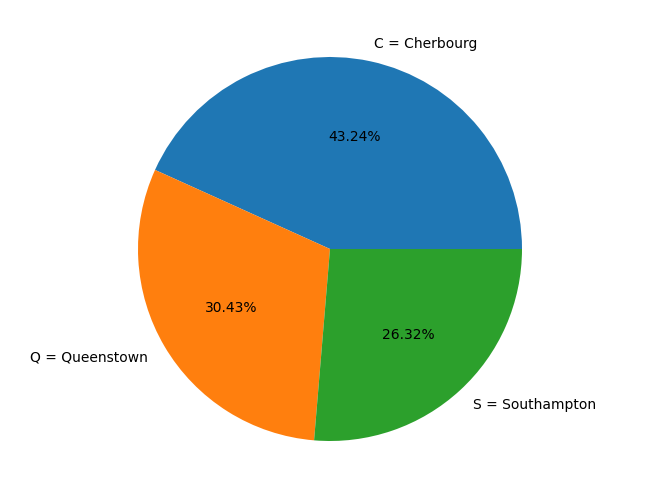

In [47]:
# Survival rate by port of embarkation

fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.axis('equal')
l = ['C = Cherbourg', 'Q = Queenstown', 'S = Southampton']
s = [0.553571,0.389610,0.336957]
ax.pie(s, labels = l,autopct='%1.2f%%')
plt.show()